The objective of this project is to analyze and forecast household energy consumption using historical time-series data. Different machine learning and statistical models such as ARIMA, Prophet, and XGBoost are applied and evaluated to determine the best-performing model.

In [3]:
# Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Models
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Warnings
import warnings
warnings.filterwarnings('ignore')

Loading the dataset

In [4]:

from google.colab import files
uploaded = files.upload()

Saving household_power_consumption.txt to household_power_consumption (1).txt


Displaying the dataset

In [5]:
# Load dataset
df = pd.read_csv('household_power_consumption.txt', sep=';', low_memory=False)

# Preview
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


## Data Preprocessing

In this step, the dataset is cleaned and transformed into a time-series format.
The Date and Time columns are combined into a single datetime column, missing values are handled,
and the dataset is indexed by datetime for proper time-based analysis.

In [9]:
# Loading dataset
df = pd.read_csv('household_power_consumption.txt', sep=';', low_memory=False)

# Clean column names
df.columns = df.columns.str.strip()

# Verify columns
print(df.columns)

# Combine Date & Time
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')

# Drop original columns
df.drop(['Date', 'Time'], axis=1, inplace=True)

# Replace '?' with NaN
df.replace('?', np.nan, inplace=True)

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Drop missing values
df.dropna(inplace=True)

# Set datetime as index
df.set_index('datetime', inplace=True)

df.head()

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
1166289840000000000,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1166289900000000000,5.360,0.436,233.63,23.0,0.0,1.0,16.0
1166289960000000000,5.374,0.498,233.29,23.0,0.0,2.0,17.0
1166290020000000000,5.388,0.502,233.74,23.0,0.0,1.0,17.0
1166290080000000000,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [10]:
df.index = pd.to_datetime(df.index)

In [11]:
print(df.index[:5])

DatetimeIndex(['2006-12-16 17:24:00', '2006-12-16 17:25:00',
               '2006-12-16 17:26:00', '2006-12-16 17:27:00',
               '2006-12-16 17:28:00'],
              dtype='datetime64[ns]', name='datetime', freq=None)


In [12]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## Time Series Resampling

The dataset is resampled from minute-level data to hourly averages
to reduce noise and improve model performance.

In [21]:
#Using only a subset of dataset
df = df.iloc[:50000]

# Resample to hourly
df_hourly = df.resample('H').mean()

# Target variable
data = df_hourly[['Global_active_power']]

data.head()

,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


## Feature Engineering

Time-based features such as hour, day, and month are extracted
to help machine learning models capture temporal patterns.

In [22]:
# Time-based features
data['hour'] = data.index.hour
data['day'] = data.index.dayofweek
data['month'] = data.index.month

display(data.head())

,Global_active_power,hour,day,month
datetime,,,,
2006-12-16 17:00:00,4.222889,17,5,12
2006-12-16 18:00:00,3.632200,18,5,12
2006-12-16 19:00:00,3.400233,19,5,12
2006-12-16 20:00:00,3.268567,20,5,12
2006-12-16 21:00:00,3.056467,21,5,12


## Train-Test Spliting

The dataset is divided into training and testing sets
to evaluate model performance on unseen data.

In [24]:
train_size = int(len(data) * 0.8)

train = data.iloc[:train_size]
test = data.iloc[train_size:]

# printing output
print(f"Training Samples: {len(train)}")
print(f"Testing Samples: {len(test)}")

Training Samples: 667
Testing Samples: 167


## Model Evaluation

The models are evaluated using Mean Absolute Error (MAE)
and Root Mean Squared Error (RMSE) to compare performance.

In [16]:
from statsmodels.tsa.arima.model import ARIMA

# Use smaller series
arima_train = train['Global_active_power'][:1000]

model_arima = ARIMA(arima_train, order=(2,1,2))
model_arima_fit = model_arima.fit()

arima_pred = model_arima_fit.forecast(steps=len(test))
arima_pred = arima_pred[:len(test)]

In [25]:
from prophet import Prophet

# Preparing data
prophet_df = data.reset_index()
prophet_df = prophet_df[['datetime', 'Global_active_power']]
prophet_df.columns = ['ds', 'y']

train_prophet = prophet_df.iloc[:train_size]
test_prophet = prophet_df.iloc[train_size:]

# Training model
model_prophet = Prophet()
model_prophet.fit(train_prophet)

# Forecasting
future = model_prophet.make_future_dataframe(periods=len(test_prophet), freq='H')
forecast = model_prophet.predict(future)

prophet_pred = forecast['yhat'].iloc[-len(test_prophet):].values

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [26]:
from xgboost import XGBRegressor

features = ['hour', 'day', 'month']

X_train = train[features]
y_train = train['Global_active_power']

X_test = test[features]
y_test = test['Global_active_power']

model_xgb = XGBRegressor(n_estimators=100, max_depth=5)
model_xgb.fit(X_train, y_train)

xgb_pred = model_xgb.predict(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ARIMA
mae_arima = mean_absolute_error(test['Global_active_power'], arima_pred)
rmse_arima = np.sqrt(mean_squared_error(test['Global_active_power'], arima_pred))

# Prophet
mae_prophet = mean_absolute_error(test_prophet['y'], prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test_prophet['y'], prophet_pred))

# XGBoost
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet", "XGBoost"],
    "MAE": [mae_arima, mae_prophet, mae_xgb],
    "RMSE": [rmse_arima, rmse_prophet, rmse_xgb]
})

# Formating values
results["MAE"] = results["MAE"].round(4)
results["RMSE"] = results["RMSE"].round(4)

# Display nicely
display(results.sort_values(by="RMSE"))

,Model,MAE,RMSE
1,Prophet,0.6656,0.9357
0,ARIMA,0.8933,1.1131
2,XGBoost,0.8971,1.2351


## Visualization

The actual and predicted energy consumption values are plotted
to visually compare model performance.

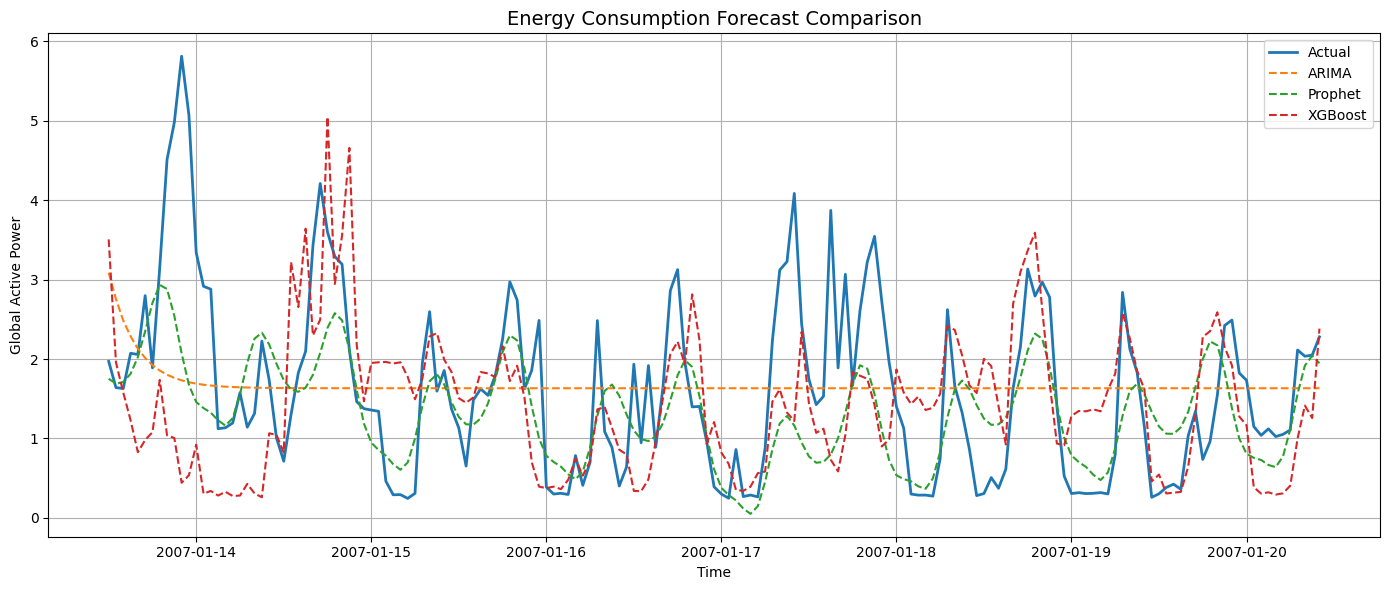

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(test.index, test['Global_active_power'], label='Actual', linewidth=2)

plt.plot(test.index, arima_pred,label='ARIMA', linestyle='--')

plt.plot(test.index, prophet_pred,label='Prophet', linestyle='--')

plt.plot(test.index, xgb_pred,label='XGBoost', linestyle='--')

plt.title("Energy Consumption Forecast Comparison", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Conclusion

This project analyzed and forecasted household energy consumption using three different models: ARIMA, Prophet, and XGBoost.

Based on evaluation metrics:

- Prophet achieved the best performance with:
  - MAE = 0.6656
  - RMSE = 0.9357

- ARIMA showed moderate performance:
  - MAE = 0.8933
  - RMSE = 1.1131

- XGBoost performed slightly worse in this case:
  - MAE = 0.8971
  - RMSE = 1.2351

These results indicate that Prophet is the most suitable model for this dataset due to its ability to capture time-based trends and seasonality effectively.

